In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('BK','MU'), 
         ('BK','CSCO'), 
         ('BK','INTC'), 
         ('CMI','MU'), 
         ('CMI', 'CSCO'),
         ('CMI', 'INTC'), 
         ('GLW','MU'), 
         ('GLW', 'CSCO'), 
         ('GLW','INTC')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

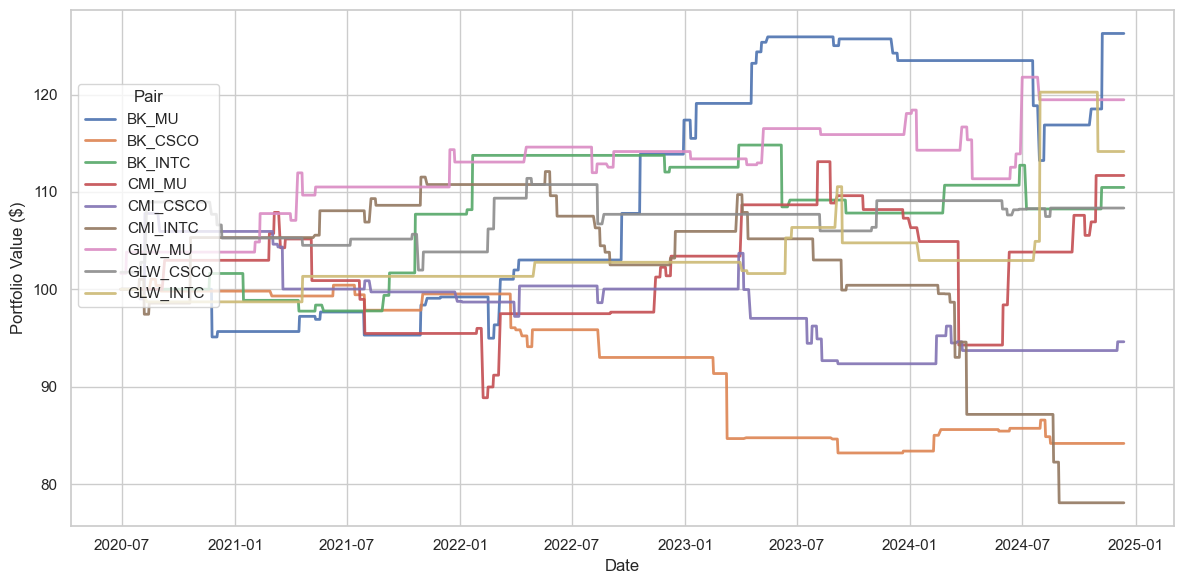

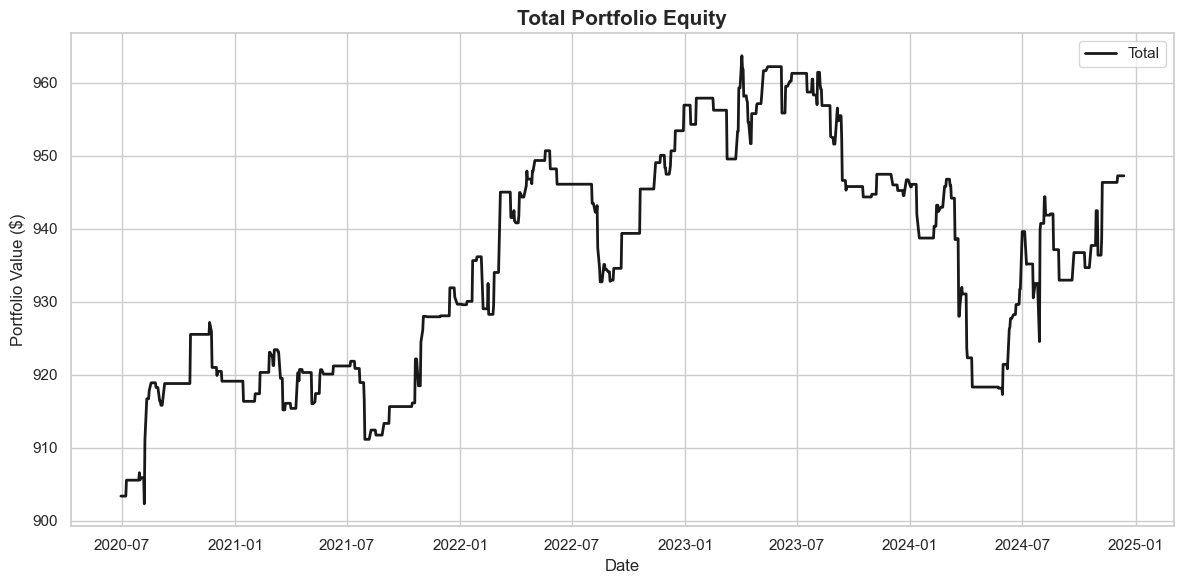

Summary
BK_MU: Final Value = $126.27, Total Return = 26.27%, Trades = 32
BK_CSCO: Final Value = $84.17, Total Return = -15.83%, Trades = 27
BK_INTC: Final Value = $110.46, Total Return = 10.46%, Trades = 20
CMI_MU: Final Value = $111.69, Total Return = 11.69%, Trades = 33
CMI_CSCO: Final Value = $94.61, Total Return = -5.39%, Trades = 29
CMI_INTC: Final Value = $78.08, Total Return = -21.92%, Trades = 34
GLW_MU: Final Value = $119.46, Total Return = 17.54%, Trades = 30
GLW_CSCO: Final Value = $108.34, Total Return = 6.48%, Trades = 27
GLW_INTC: Final Value = $114.15, Total Return = 14.15%, Trades = 14

Total Portfolio Performance
Initial Portfolio Value: $903.39
Final Portfolio Value:   $947.23
Total Return:            4.85%

Sharpe Ratios
BK_MU: Sharpe Ratio = 0.71
BK_CSCO: Sharpe Ratio = -0.77
BK_INTC: Sharpe Ratio = 0.41
CMI_MU: Sharpe Ratio = 0.30
CMI_CSCO: Sharpe Ratio = -0.16
CMI_INTC: Sharpe Ratio = -0.64
GLW_MU: Sharpe Ratio = 0.63
GLW_CSCO: Sharpe Ratio = 0.32
GLW_INTC: Sharpe

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)